# IRIS data set classification using SVM and GridSearch

Here is the little description about Iris dataset. 

The data set consists of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

Setosa flower

![](http://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg)

Versicolor flower

![](http://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg)

Virginica flower

![](http://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg)

### What is SVM ?
SVM is a powerful and flexible class of supervised algorithms for both classification and regression.
Support Vectors are the simple co-oridnates of individual obeservation. 
Support Vecrtor Machine(SVM) is a borderline/boundary/limit which segregates the features.

### How to draw the line ?
The simplest way to interpret the objective function in a SVM is to find the minimum distance of the frontier from the closest support vector. Once we have these distances for all the frontiers, we simply choose the frontier with the maximum distance(i.e from the closest support vector ).

For simple cases it is easy to find a straight line to classify the features. But in some cases, we need to map a vector to a higher dimension plane so that they get segregated from each other. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import svm, datasets

Let us import the Iris data set

In [2]:
data = pd.read_csv("Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


Let us create a pairplot of the data set

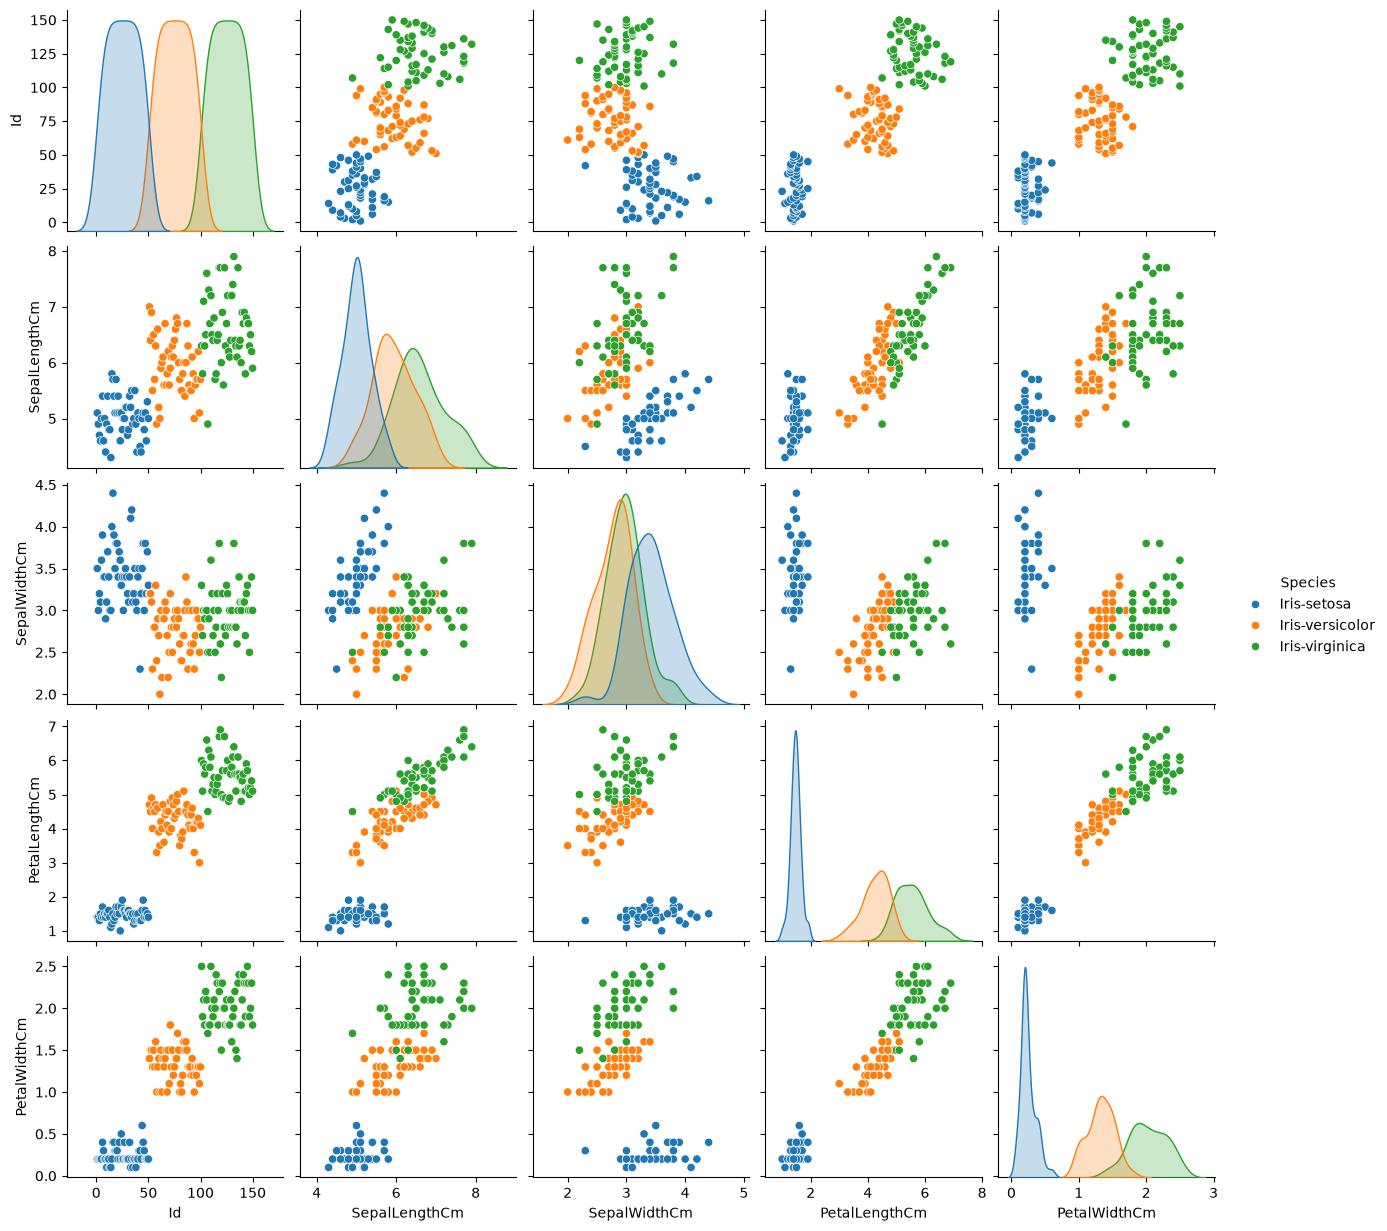

In [4]:
sns.pairplot(data, hue = 'Species');

Create a kde plot of sepal length versus sepal width for versicolor flower

<Axes: xlabel='SepalWidthCm', ylabel='SepalLengthCm'>

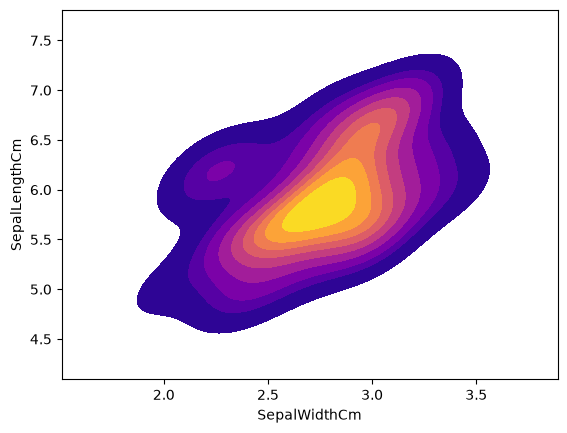

In [5]:
# versicolor = data[data['Species'] == 'Iris-versicolor']
# sns.kdeplot( x=versicolor['SepalWidthCm'], y=versicolor['SepalLengthCm'], 
#             cmap='plasma', shade=True, shade_lowest=False)


versicolor = data[data['Species'] == 'Iris-versicolor']
sns.kdeplot(
    x=versicolor['SepalWidthCm'], 
    y=versicolor['SepalLengthCm'], 
    cmap='plasma', 
    fill=True,       # Replaces shade=True
    thresh=0.05      # Replaces shade_lowest=False (adjust thresh value if needed)
)

Split the data as Train and Test sets

In [6]:
from sklearn.model_selection import train_test_split
X = data.drop(['Id', 'Species'], axis = 1)
y = data['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1023)

It's time to train the model 

In [7]:
from sklearn.svm import SVC
svm = SVC(kernel='sigmoid')
svm.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Let us do the predictions using the trained model

In [8]:
pred = svm.predict(X_test)

Create confusion matrix

In [9]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, pred))

[[ 0 17  0]
 [ 0 13  0]
 [ 0 15  0]]


Create classification report

In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred))

                 precision    recall  f1-score   support

    Iris-setosa       0.00      0.00      0.00        17
Iris-versicolor       0.29      1.00      0.45        13
 Iris-virginica       0.00      0.00      0.00        15

       accuracy                           0.29        45
      macro avg       0.10      0.33      0.15        45
   weighted avg       0.08      0.29      0.13        45



D:\anaconda3\envs\TugasBDA\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda3\envs\TugasBDA\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda3\envs\TugasBDA\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
svm.score(X_test,y_test)

0.28888888888888886

###  Grid Search
Now we will tune the parameters, check for the improvement

Tuning parameters value for machine learning algorithms effectively improves the model performance ( Let us check in for our data)

Import Gridsearch from Scikit Learn.

In [12]:
from sklearn.model_selection import GridSearchCV

Create a dictionary called param_grid and fill out some parameters for C and Gamma

In [13]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001, 'scale'],
    'coef0': [-2, -1, 0, 1, 2],
}

Create a GridSearchCV object and fit it to the training data

Grid search is a model hyperparameter optimization technique.

In [14]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC

# Outer CV: splits X_train into 5 folds
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1023)

# Inner CV: used by GridSearchCV to evaluate candidates on each fold
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
fold_params = []

print("=== Running GridSearchCV Across Every Cross-Validation Fold ===")

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), 1):
    X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Run GridSearchCV exclusively on the training partition of this fold
    grid_fold = GridSearchCV(
        estimator=SVC(kernel='sigmoid'),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        refit=True
    )
    grid_fold.fit(X_tr_fold, y_tr_fold)
    
    # Evaluate best estimator of this fold on the outer fold's validation slice
    score = grid_fold.score(X_val_fold, y_val_fold)
    fold_scores.append(score)
    fold_params.append(grid_fold.best_params_)
    
    print(f"Fold {fold_idx}: Best Params = {grid_fold.best_params_} | Validation Accuracy = {score:.4f}")

# Cross-validation mean and standard deviation
print("\n=== Cross-Validation Results ===")
print(f"Fold Accuracies:     {[round(s, 4) for s in fold_scores]}")
print(f"Mean CV Accuracy:    {np.mean(fold_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(fold_scores):.4f}")

# Final model fit on full X_train so cells In [15] through In [18] work seamlessly
grid = GridSearchCV(SVC(kernel='sigmoid'), param_grid, cv=inner_cv, refit=True)
grid.fit(X_train, y_train)

=== Running GridSearchCV Across Every Cross-Validation Fold ===
Fold 1: Best Params = {'C': 100, 'coef0': -1, 'gamma': 0.01} | Validation Accuracy = 1.0000
Fold 2: Best Params = {'C': 100, 'coef0': -1, 'gamma': 0.01} | Validation Accuracy = 1.0000
Fold 3: Best Params = {'C': 100, 'coef0': -1, 'gamma': 0.01} | Validation Accuracy = 0.9524
Fold 4: Best Params = {'C': 100, 'coef0': -1, 'gamma': 0.01} | Validation Accuracy = 0.9524
Fold 5: Best Params = {'C': 100, 'coef0': -1, 'gamma': 0.01} | Validation Accuracy = 0.9524

=== Cross-Validation Results ===
Fold Accuracies:     [1.0, 1.0, 0.9524, 0.9524, 0.9524]
Mean CV Accuracy:    0.9714
Std Dev CV Accuracy: 0.0233


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='sigmoid')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'coef0': [-2, -1, ...], 'gamma': [1, 0.1, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls

In [15]:
# best_idx = grid.best_index_
# best_mean = grid.cv_results_['mean_test_score'][best_idx]
# best_std = grid.cv_results_['std_test_score'][best_idx]
# fold_scores = [grid.cv_results_[f'split{i}_test_score'][best_idx] for i in range(5)]

# print("=== Best Hyperparameters Cross-Validation Performance ===")
# print(f"Optimal Parameters: {grid.best_params_}")
# print(f"Score per Fold:     {[round(score, 4) for score in fold_scores]}")
# print(f"Mean CV Accuracy:   {best_mean:.4}")
# print(f"Std Dev CV:         {best_std:.4}")

Let us predict using the Grid model

In [16]:
pred_grid = grid.predict(X_test)

Let us compute the confusion matrix

In [17]:
print(confusion_matrix(y_test, pred_grid))

[[17  0  0]
 [ 0 12  1]
 [ 0  0 15]]


Let us print the report also

In [18]:
print(classification_report(y_test, pred_grid))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.94      1.00      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.98        45
   weighted avg       0.98      0.98      0.98        45



In [19]:
grid.best_params_

{'C': 100, 'coef0': -1, 'gamma': 0.01}